In [44]:
%matplotlib inline
import trace
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

df_path = "trace_summary_combined.csv"

short_think_names = {
    'claude-sonnet-4-20250514-t1.0': 'CL-4',
    'claude-sonnet-4-20250514-t0.0': 'CL-4',
    'deepseek-r1-distill-llama-70b-t1.0':'LM-70B',
    'gpt-oss-120b-t1.0':'GPT-OSS',
    'nemotron-nano-9b-v2-t1.0':'Nem-9B',
    'qwen3-next-80b-a3b-thinking-t1.0':'Qwen-3'
}

def shorten_model_names(df):
    df['model'] = df['model'].map(short_think_names)
    return df

df = pd.read_csv(df_path)
trace_df = shorten_model_names(df)
# Make percentages out of author_role
trace_df['author_role'] = trace_df['author_role'] * 100
trace_df['user_mentioned'] = trace_df['user_mentioned'] * 100
trace_df['role_awareness'] = trace_df['role_awareness'] * 100
trace_df['loops'] = trace_df['loops'] * 100
# print dimensions of dataframe
print(trace_df.shape)
trace_df.head()

(309, 25)


,game_language,model,game,experiment,instance,author_role,agentive_persons,user_mentioned,player_count,role_awareness,...,suspects_deception,intends_deception,main_score,response_rate,aborted,lose,success,thinking_length,response_length,ratio_thinking_response
0,en,LM-70B,hot_air_balloon,air_balloon_survival_en_negotiation_hard,4,100.0,1.0,0.0,2.0,100.0,...,0.0,0.2,0.0,1.0,1,0,0,37880,1889,0.049868
1,en,LM-70B,hot_air_balloon,air_balloon_survival_en_reasoning off_hard,5,100.0,1.6,0.0,2.0,100.0,...,0.0,0.0,0.0,1.0,1,0,0,32160,715,0.022233
2,en,LM-70B,hot_air_balloon,air_balloon_survival_en_negotiation_easy,4,100.0,1.0,60.0,2.0,100.0,...,0.0,0.0,0.0,1.0,1,0,0,30715,1607,0.052320
3,en,LM-70B,hot_air_balloon,air_balloon_survival_en_reasoning off_easy,5,100.0,0.8,60.0,1.8,80.0,...,0.0,0.0,0.0,1.0,1,0,0,32246,1053,0.032655
4,en,LM-70B,hot_air_balloon,air_balloon_survival_en_complexity_hard,3,40.0,1.6,60.0,2.0,40.0,...,0.0,0.2,0.0,1.0,1,0,0,14289,2410,0.168661


In [45]:
# print column names
print(trace_df.columns)

Index(['game_language', 'model', 'game', 'experiment', 'instance',
       'author_role', 'agentive_persons', 'user_mentioned', 'player_count',
       'role_awareness', 'loops', 'frustration', 'confusion', 'excitement',
       'trace_language_count', 'suspects_deception', 'intends_deception',
       'main_score', 'response_rate', 'aborted', 'lose', 'success',
       'thinking_length', 'response_length', 'ratio_thinking_response'],
      dtype='object')


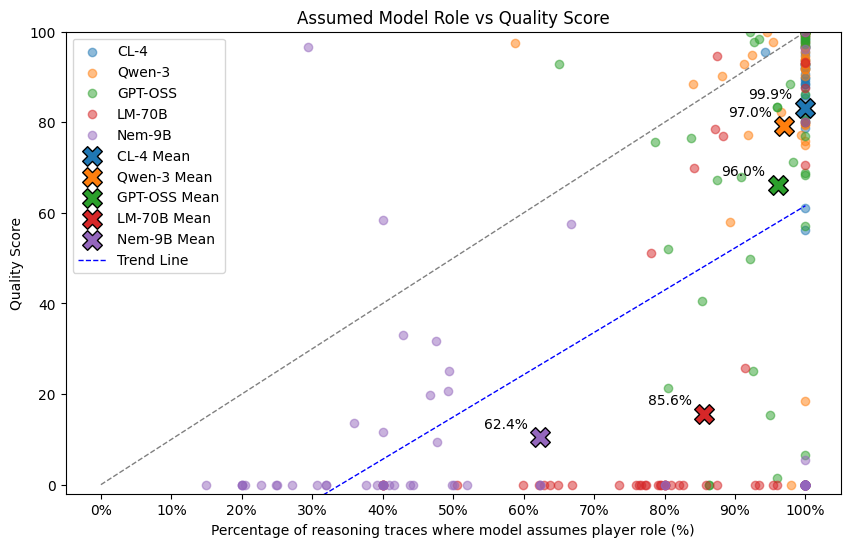

In [129]:
models = trace_df['model'].unique()

# Sort models by average main_score descending
model_means = trace_df.groupby('model')['main_score'].mean().sort_values(ascending=False)
models = model_means.index.tolist()

# plt.style.use('tableau-colorblind10')
fig, ax = plt.subplots(figsize=(10, 6))
# scatter plot with different colors for each model
# x-axis: author_role, y-axis: main_score
# Overlay two scatter plots: one for individual points, one for averages. Use same color for both.
for i, model in enumerate(models):
    model_df = df[df['model'] == model]
    color = plt.cm.tab10(i)  # Get a color from the tab10 colormap
    ax.scatter(model_df['author_role'], model_df['main_score'], label=model, alpha=0.5, color=color)
for i, model in enumerate(models):
    model_df = df[df['model'] == model]
    color = plt.cm.tab10(i)  # Get a color from the tab10 colormap
    main_score_mean = model_df['main_score'].mean()
    author_role_mean = model_df['author_role'].mean()
    ax.scatter(author_role_mean, main_score_mean, label=f'{model} Mean', s=200, edgecolor='black', color=color, marker='X')
    # label the mean points with the respective percentages
    ax.text(author_role_mean - 8, main_score_mean + 2, f'{author_role_mean:.1f}%', fontsize=10)
# horizontal line at y=50

# diagonal line from (0,0) to (100,100)
ax.plot([0, 100], [0, 100], color='gray', linestyle='--', linewidth=1)

# add trend line
z = np.polyfit(df['author_role'], df['main_score'], 1)
p = np.poly1d(z)
t_x = np.linspace(0, 100, 100)
ax.plot(t_x, p(t_x), color='blue', linestyle='--', linewidth=1, label='Trend Line')

ax.set_ylim(-2, 100)

# make lines at x=50 and y=50
# ax.axhline(y=50, color='gray', linestyle='--', linewidth=1, label='Quality Score = 50')
# ax.axvline(x=50, color='gray', linestyle='--', linewidth=1, label='Assumed Role = 50%')

# make x ticks percentages
ax.set_xticks(np.arange(0, 101, 10))
# make x tick labels percentages
ax.set_xticklabels([f'{i}%' for i in range(0, 101, 10)])
ax.set_xlabel('Percentage of reasoning traces where model assumes player role (%)')
ax.set_ylabel('Quality Score')
ax.set_title('Assumed Model Role vs Quality Score')
ax.legend()
plt.savefig('author_role_vs_quality_score.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [80]:
# find out how many points are above the diagonal line and how many are below
above_and_right_total = 0
above_and_left_total = 0
below_and_right_total = 0
below_and_left_total = 0
for i, model in enumerate(models):
    model_df = df[df['model'] == model]
    above_and_right = ((model_df['author_role'] > 50) & (model_df['main_score'] > 50)).sum()
    above_and_left = ((model_df['author_role'] <= 50) & (model_df['main_score'] > 50)).sum()
    below_and_right = ((model_df['author_role'] > 50) & (model_df['main_score'] <= 50)).sum()
    below_and_left = ((model_df['author_role'] <= 50) & (model_df['main_score'] <= 50)).sum()
    total = above_and_right + above_and_left + below_and_right + below_and_left
    above_and_right_total += above_and_right
    above_and_left_total += above_and_left
    below_and_right_total += below_and_right
    below_and_left_total += below_and_left
    print(f'{model}: {above_and_right} above and right, {above_and_left} above and left, {below_and_right} below and right, {below_and_left} below and left')
    print(f'{model} Percentages: {above_and_right/total:.2%} above and right, {above_and_left/total:.2%} above and left, {below_and_right/total:.2%} below and right, {below_and_left/total:.2%} below and left')
grand_total = above_and_right_total + above_and_left_total + below_and_right_total + below_and_left_total
print(f'Overall: {above_and_right_total} above and right, {above_and_left_total} above and left, {below_and_right_total} below and right, {below_and_left_total} below and left')
print(f'Overall Percentages: {above_and_right_total/grand_total:.2%} above and right, {above_and_left_total/grand_total:.2%} above and left, {below_and_right_total/grand_total:.2%} below and right, {below_and_left_total/grand_total:.2%} below and left')

CL-4: 56 above and right, 0 above and left, 7 below and right, 0 below and left
CL-4 Percentages: 88.89% above and right, 0.00% above and left, 11.11% below and right, 0.00% below and left
Qwen-3: 51 above and right, 0 above and left, 8 below and right, 1 below and left
Qwen-3 Percentages: 85.00% above and right, 0.00% above and left, 13.33% below and right, 1.67% below and left
GPT-OSS: 42 above and right, 0 above and left, 17 below and right, 0 below and left
GPT-OSS Percentages: 71.19% above and right, 0.00% above and left, 28.81% below and right, 0.00% below and left
LM-70B: 12 above and right, 0 above and left, 49 below and right, 3 below and left
LM-70B Percentages: 18.75% above and right, 0.00% above and left, 76.56% below and right, 4.69% below and left
Nem-9B: 4 above and right, 2 above and left, 26 below and right, 31 below and left
Nem-9B Percentages: 6.35% above and right, 3.17% above and left, 41.27% below and right, 49.21% below and left
Overall: 165 above and right, 2 ab

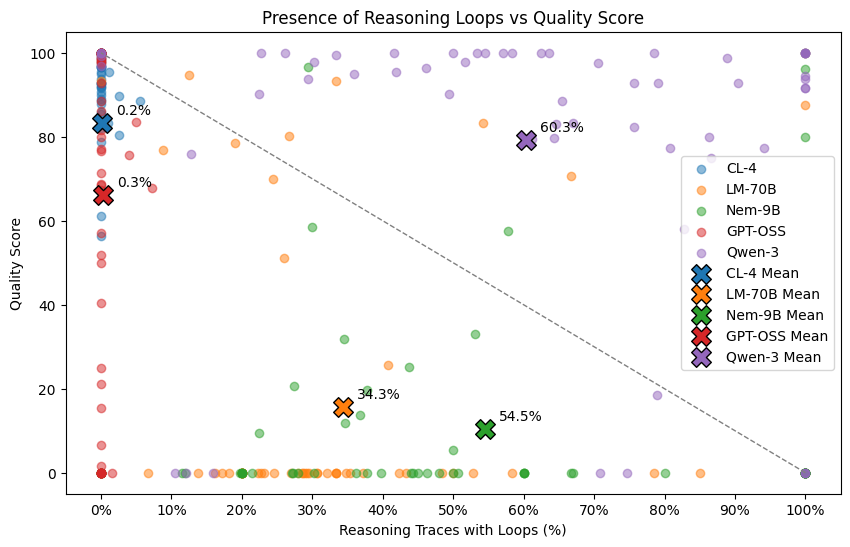

In [135]:
fig, ax = plt.subplots(figsize=(10, 6))

# scatter plot with different colors for each model
for i, model in enumerate(models):
    model_df = df[df['model'] == model]
    ax.scatter(model_df['loops'], model_df['main_score'], label=model, color=plt.cm.tab10(i), alpha=0.5)
for i, model in enumerate(models):
    model_df = df[df['model'] == model]
    main_score_mean = model_df['main_score'].mean()
    loops_mean = model_df['loops'].mean()
    ax.scatter(loops_mean, main_score_mean, label=f'{model} Mean', s=200, edgecolor='black', marker='X', color=plt.cm.tab10(i))
    # label the mean points with the loop percentages
    ax.text(loops_mean + 2, main_score_mean + 2, f'{loops_mean:.1f}%', fontsize=10)

# # add trend line
# z = np.polyfit(df['loops'], df['main_score'], 1)
# p = np.poly1d(z)
# x = np.linspace(0, 100, 100)
# ax.plot(x, p(x), color='blue', linestyle='--', linewidth=1, label='Trend Line')

# add diagonal line from main_score=100 to loops=100
ax.plot([100, 0], [0, 100], color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('Reasoning Traces with Loops (%)')
ax.set_xticks(np.arange(0, 101, 10))
ax.set_xticklabels([f'{i}%' for i in range(0, 101, 10)])
ax.set_ylabel('Quality Score')
ax.set_title('Presence of Reasoning Loops vs Quality Score')
ax.legend()
plt.savefig('loops_vs_quality_score.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [49]:
above_total = 0
below_total = 0
qwen3_above = 0
qwen3_below = 0
for i, model in enumerate(models):
    model_df = df[df['model'] == model]
    above = ((100 - model_df['loops'] < model_df['main_score']).sum())
    below = ((100 - model_df['loops'] >= model_df['main_score']).sum())
    if model == 'Qwen-3':
        qwen3_above = above
        qwen3_below = below
    total = above + below
    print(f'{model}: {above} above, {below} below, {above/total:.2%} above')
    above_total += above
    below_total += below
total = above_total + below_total
print(f'Overall: {above_total}/{total} above, {below_total} below, {above_total/total:.2%} above, {below_total/total:.2%} below')
print(f'Overall without CL-4: {above_total - qwen3_above}/{total - (qwen3_above + qwen3_below)} above, {below_total - qwen3_below} below, {(above_total - qwen3_above)/(total - (qwen3_above + qwen3_below)):.2%} above, {(below_total - qwen3_below)/(total - (qwen3_above + qwen3_below)):.2%} below')

CL-4: 0 above, 63 below, 0.00% above
Qwen-3: 45 above, 15 below, 75.00% above
GPT-OSS: 0 above, 59 below, 0.00% above
LM-70B: 7 above, 57 below, 10.94% above
Nem-9B: 5 above, 58 below, 7.94% above
Overall: 57/309 above, 252 below, 18.45% above, 81.55% below
Overall without CL-4: 12/249 above, 237 below, 4.82% above, 95.18% below


In [50]:
reasoning_graph_summary_df = pd.read_csv('reasoning_summary_per_episode.csv')
reasoning_graph_summary_df = shorten_model_names(reasoning_graph_summary_df)
reasoning_graph_summary_df = reasoning_graph_summary_df.drop(columns=["reasoning_raw", "reasoning_labels"])

# shorten instance to everything after `_`, make numeric
reasoning_graph_summary_df['episode'] = reasoning_graph_summary_df['episode'].apply(lambda x: int(x.split('_')[-1]) if isinstance(x, str) and x.split('_')[-1].isdigit() else x)
reasoning_graph_summary_df['episode'] = pd.to_numeric(reasoning_graph_summary_df['episode'], errors='coerce')
reasoning_graph_summary_df = reasoning_graph_summary_df.dropna(subset=['episode'])
reasoning_graph_summary_df['episode'] = reasoning_graph_summary_df['episode'].astype(int)

# add 1 to all n_segment values to avoid faulty 0-segments
reasoning_graph_summary_df['n_segment'] = reasoning_graph_summary_df['n_segment'] + 1

# rename 'episode' to 'instance'
reasoning_graph_summary_df = reasoning_graph_summary_df.rename(columns={'episode': 'instance'})
reasoning_graph_summary_df.head()

df_combined = reasoning_graph_summary_df.merge(
        df,
        left_on=['model', 'game', 'experiment', 'instance'],
        right_on=['model', 'game', 'experiment', 'instance'],
        how='inner'  
    )

df_combined.head()

,lang,model,game,experiment,instance,reasoning_chain_len,reasoning_chain_avg_len,reasoning_chain_ratio,n_segment,cycle_edge_ratio,...,suspects_deception,intends_deception,main_score,response_rate,aborted,lose,success,thinking_length,response_length,ratio_thinking_response
0,en,CL-4,hot_air_balloon,air_balloon_survival_en_negotiation_hard,4,"[1, 4, 2]",2.333333,0.207246,1.333333,0.333333,...,0.000000,0.0,85.330412,1.0,0,0,1,7963,6884,0.864498
1,en,CL-4,hot_air_balloon,air_balloon_survival_en_negotiation_hard,1,[2],2.000000,0.064516,2.000000,0.000000,...,0.150000,0.0,78.689633,1.0,0,0,1,11656,8702,0.746568
2,en,CL-4,hot_air_balloon,air_balloon_survival_en_reasoning off_hard,5,"[2, 4]",3.000000,0.228571,1.500000,0.500000,...,0.153846,0.0,82.021605,1.0,0,0,1,20607,10841,0.526083
3,en,CL-4,hot_air_balloon,air_balloon_survival_en_reasoning off_hard,4,"[3, 3]",3.000000,0.162260,2.000000,0.500000,...,0.000000,0.0,91.956483,1.0,0,0,1,8579,3797,0.442592
4,en,CL-4,hot_air_balloon,air_balloon_survival_en_negotiation_easy,3,[2],2.000000,0.042553,1.000000,0.000000,...,0.000000,0.0,96.705615,1.0,0,0,1,6143,3170,0.516035


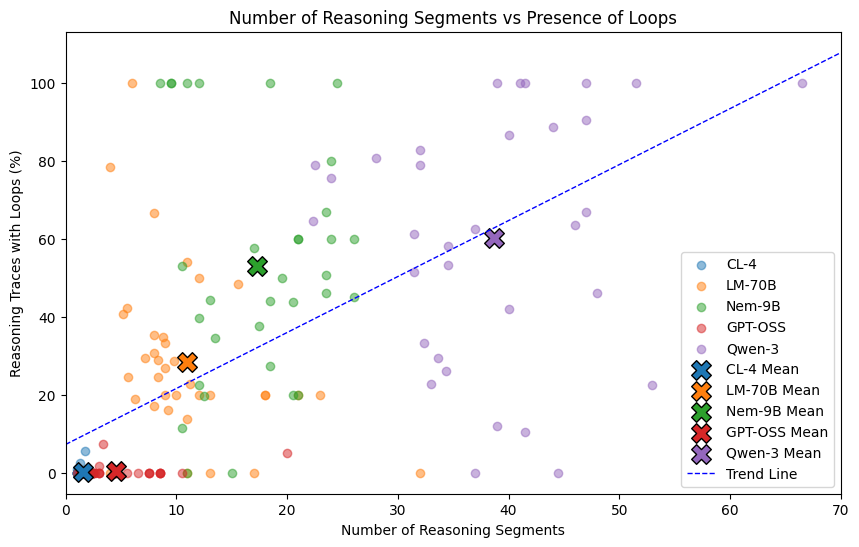

In [133]:

# make scatterplot of loops vs n_segment, color by model
fig, ax = plt.subplots(figsize=(10, 6))
models = df_combined['model'].unique()
for i, model in enumerate(models):
    model_df = df_combined[df_combined['model'] == model]
    ax.scatter(model_df['n_segment'], model_df['loops'], label=model, color=plt.cm.tab10(i), alpha=0.5)
for i, model in enumerate(models):
    model_df = df_combined[df_combined['model'] == model]
    n_segments_mean = model_df['n_segment'].mean()
    loops_mean = model_df['loops'].mean()
    ax.scatter(n_segments_mean, loops_mean, label=f'{model} Mean', s=200, edgecolor='black', marker='X', color=plt.cm.tab10(i))

# add trend line
z = np.polyfit(df_combined['n_segment'], df_combined['loops'], 1)
p = np.poly1d(z)
t_x = np.linspace(0, 70, 100)
ax.plot(t_x, p(t_x), color='blue', linestyle='--', linewidth=1, label='Trend Line')

ax.set_xlabel('Number of Reasoning Segments')
ax.set_ylabel('Reasoning Traces with Loops (%)')
ax.set_title('Number of Reasoning Segments vs Presence of Loops')
# x-axis from 0 to 70
ax.set_xlim(0, 70)
ax.legend()
plt.savefig('n_segments_vs_loops.pdf', format='pdf', bbox_inches='tight')
plt.show()

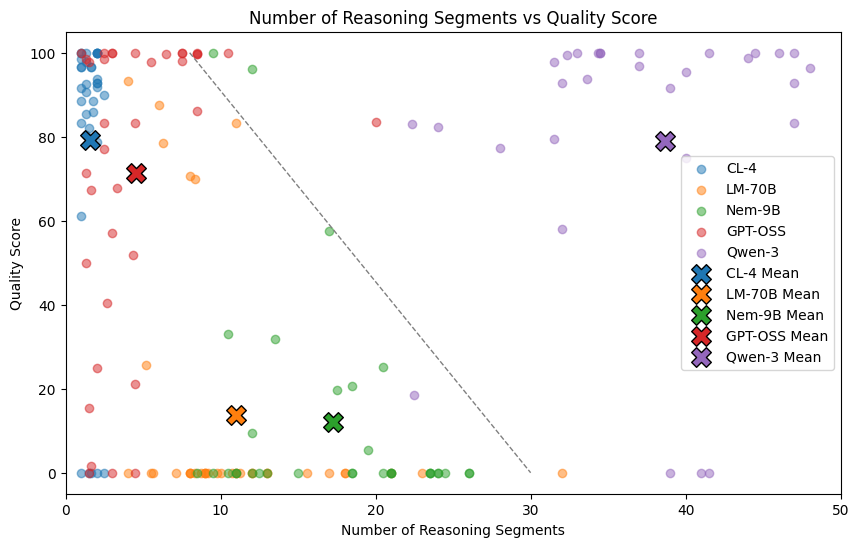

In [ ]:
# make scatterplot of main_score vs n_segment, color by model
fig, ax = plt.subplots(figsize=(10, 6))
models = df_combined['model'].unique()
for i, model in enumerate(models):
    model_df = df_combined[df_combined['model'] == model]
    ax.scatter(model_df['n_segment'], model_df['main_score'], label=model, color=plt.cm.tab10(i), alpha=0.5)
for i, model in enumerate(models):
    model_df = df_combined[df_combined['model'] == model]
    n_segments_mean = model_df['n_segment'].mean()
    main_score_mean = model_df['main_score'].mean()
    ax.scatter(n_segments_mean, main_score_mean, label=f'{model} Mean', s=200, edgecolor='black', marker='X', color=plt.cm.tab10(i))
ax.set_xlabel('Number of Reasoning Segments')
ax.set_ylabel('Quality Score')
ax.set_title('Number of Reasoning Segments vs Quality Score')
# x-axis from 0 to 70
ax.set_xlim(0, 50)
# add line from n_segment=10, main_score=100 to n_segment=35, main_score=0
ax.plot([8, 30], [100, 0], color='gray', linestyle='--', linewidth=1)

ax.legend()
# plt.savefig('n_segment_vs_quality_score.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [53]:
below = 0
above = 0
for i, model in enumerate(models):
    model_df = df_combined[df_combined['model'] == model]
    above_model = ((model_df['n_segment'] * -3 + 124 < model_df['main_score']).sum())
    below_model = ((model_df['n_segment'] * -3 + 124 >= model_df['main_score']).sum())
    total = above_model + below_model
    print(f'{model}: {above_model} above, {below_model} below, {above_model/total:.2%} above')
    above += above_model
    below += below_model
total = above + below
print(f'Overall: {above}/{total} above, {below} below, {above/total:.2%} above')

CL-4: 0 above, 36 below, 0.00% above
LM-70B: 0 above, 37 below, 0.00% above
Nem-9B: 2 above, 31 below, 6.06% above
GPT-OSS: 5 above, 31 below, 13.89% above
Qwen-3: 30 above, 3 below, 90.91% above
Overall: 37/175 above, 138 below, 21.14% above


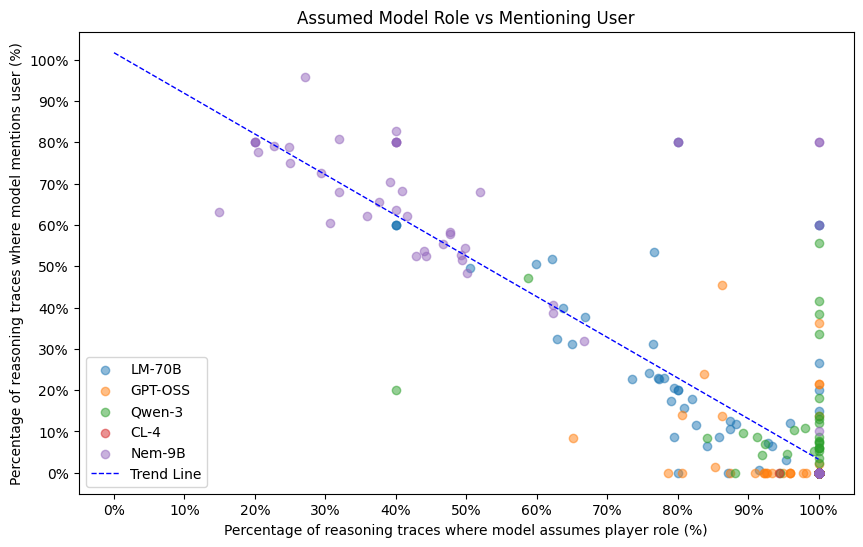

In [137]:
# scatter plot of author_role vs user_mentioned

fig, ax = plt.subplots(figsize=(10, 6))
models = trace_df['model'].unique()
for i, model in enumerate(models):
    model_df = trace_df[trace_df['model'] == model]
    ax.scatter(model_df['author_role'], model_df['user_mentioned'], label=model, color=plt.cm.tab10(i), alpha=0.5)

# add trend line
z = np.polyfit(df['author_role'], df['user_mentioned'], 1)
p = np.poly1d(z)
t_x = np.linspace(0, 100, 100)
ax.plot(t_x, p(t_x), color='blue', linestyle='--', linewidth=1, label='Trend Line')

ax.set_xlabel('Percentage of reasoning traces where model assumes player role (%)')
ax.set_ylabel('Percentage of reasoning traces where model mentions user (%)')
ax.set_title('Assumed Model Role vs Mentioning User')
ax.set_xticks(np.arange(0, 101, 10))
ax.set_xticklabels([f'{i}%' for i in range(0, 101, 10)])
ax.set_yticks(np.arange(0, 101, 10))
ax.set_yticklabels([f'{i}%' for i in range(0, 101, 10)])
ax.legend()
plt.savefig('author_role_vs_user_mentioned.pdf', format='pdf', bbox_inches='tight')
plt.show()


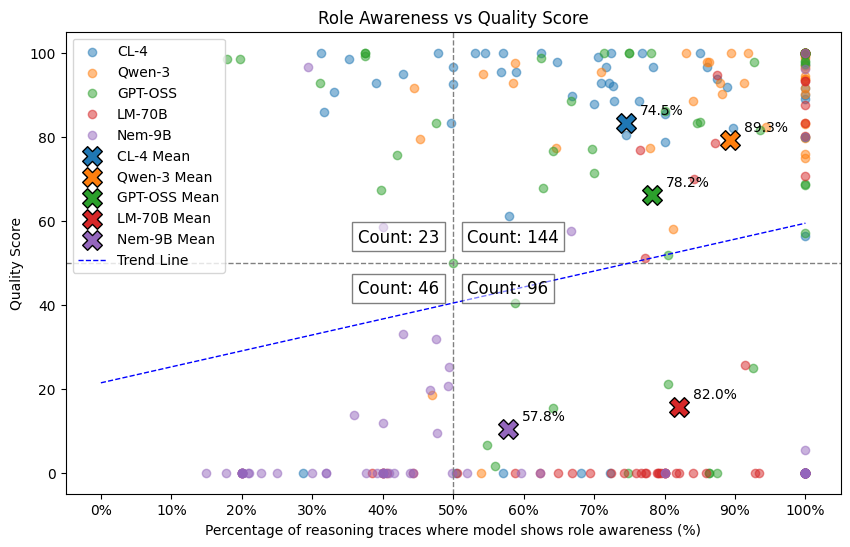

In [ ]:
# scatter plot of role_awareness vs main_score
fig, ax = plt.subplots(figsize=(10, 6))
for i, model in enumerate(models):
    model_df = df[df['model'] == model]
    color = plt.cm.tab10(i)  # Get a color from the tab10 colormap
    ax.scatter(model_df['role_awareness'], model_df['main_score'], label=model, alpha=0.5, color=color)
for i, model in enumerate(models):
    model_df = df[df['model'] == model]
    color = plt.cm.tab10(i)  # Get a color from the tab10 colormap
    main_score_mean = model_df['main_score'].mean()
    role_awareness_mean = model_df['role_awareness'].mean()
    ax.scatter(role_awareness_mean, main_score_mean, label=f'{model} Mean', s=200, edgecolor='black', color=color, marker='X')
    # label the mean points with the respective percentages
    ax.text(role_awareness_mean + 2, main_score_mean + 2, f'{role_awareness_mean:.1f}%', fontsize=10)

# total count of data points in first quadrant (x>50, y>50)
first_quadrant_count = ((df['role_awareness'] > 50) & (df['main_score'] > 50)).sum()
# label the first quadrant count in the plot
ax.text(52, 54, f'Count: {first_quadrant_count}', fontsize=12, color='black', va="bottom", bbox=dict(facecolor='white', alpha=0.5))
# total count of data points in second quadrant (x<=50, y>50)
second_quadrant_count = ((df['role_awareness'] <= 50) & (df['main_score'] > 50)).sum()
# label the second quadrant count in the plot
ax.text(48, 54, f'Count: {second_quadrant_count}', fontsize=12, color='black', ha="right", va="bottom", bbox=dict(facecolor='white', alpha=0.5))
# total count of data points in third quadrant (x<=50, y<=50)
third_quadrant_count = ((df['role_awareness'] <= 50) & (df['main_score'] <= 50)).sum()
# label the third quadrant count in the plot
ax.text(48, 46, f'Count: {third_quadrant_count}', fontsize=12, color='black', ha="right", va="top", bbox=dict(facecolor='white', alpha=0.5))
# total count of data points in fourth quadrant (x>50, y<=50)
fourth_quadrant_count = ((df['role_awareness'] > 50) & (df['main_score'] <= 50)).sum()
# label the fourth quadrant count in the plot
ax.text(52, 46, f'Count: {fourth_quadrant_count}', fontsize=12, color='black', ha="left", va="top", bbox=dict(facecolor='white', alpha=0.5))

# horizontal line at y=50
ax.axhline(y=50, color='gray', linestyle='--', linewidth=1)
# vertical line at x=50
ax.axvline(x=50, color='gray', linestyle='--', linewidth=1)

# polyfit line
z = np.polyfit(df['role_awareness'], df['main_score'], 1)
p = np.poly1d(z)
t_x = np.linspace(0, 100, 100)
ax.plot(t_x, p(t_x), color='blue', linestyle='--', linewidth=1, label='Trend Line')

# make x ticks percentages
ax.set_xticks(np.arange(0, 101, 10))
# make x tick labels percentages
ax.set_xticklabels([f'{i}%' for i in range(0, 101, 10)])
ax.set_xlabel('Percentage of reasoning traces where model shows role awareness (%)')
ax.set_ylabel('Quality Score')
ax.set_title('Role Awareness vs Quality Score')
ax.legend()
plt.savefig('role_awareness_vs_quality_score.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [ ]:
above_and_right_total = 0
above_and_left_total = 0
below_and_right_total = 0
below_and_left_total = 0
for i, model in enumerate(models):
    model_df = df[df['model'] == model]
    above_and_right = ((model_df['role_awareness'] > 50) & (model_df['main_score'] > 50)).sum()
    above_and_left = ((model_df['role_awareness'] <= 50) & (model_df['main_score'] > 50)).sum()
    below_and_right = ((model_df['role_awareness'] > 50) & (model_df['main_score'] <= 50)).sum()
    below_and_left = ((model_df['role_awareness'] <= 50) & (model_df['main_score'] <= 50)).sum()
    total = above_and_right + above_and_left + below_and_right + below_and_left
    print(f'{model}: {above_and_right} above and right, {above_and_left} above and left, {below_and_right} below and right, {below_and_left} below and left')
    above_and_right_total += above_and_right
    above_and_left_total += above_and_left
    below_and_right_total += below_and_right
    below_and_left_total += below_and_left
total = above_and_right_total + above_and_left_total + below_and_right_total + below_and_left_total
print(f'Overall: {above_and_right_total}/{total} above and right, {above_and_left_total} above and left, {below_and_right_total} below and right, {below_and_left_total} below and left')
print(f'Overall Percentages: {above_and_right_total/total:.2%} above and right, {above_and_left_total/total:.2%} above and left, {below_and_right_total/total:.2%} below and right, {below_and_left_total/total:.2%} below and left')

LM-70B: 12 above and right, 0 above and left, 45 below and right, 7 below and left
GPT-OSS: 33 above and right, 9 above and left, 16 below and right, 1 below and left
Qwen-3: 49 above and right, 2 above and left, 7 below and right, 2 below and left
CL-4: 46 above and right, 10 above and left, 6 below and right, 1 below and left
Nem-9B: 4 above and right, 2 above and left, 22 below and right, 35 below and left
Overall: 144/309 above and right, 23 above and left, 96 below and right, 46 below and left
Overall Percentages: 46.60% above and right, 7.44% above and left, 31.07% below and right, 14.89% below and left


In [78]:
clean_up_df = trace_df[trace_df['game'] == 'clean_up']
above_and_right = ((clean_up_df['role_awareness'] > 50) & (clean_up_df['main_score'] > 50)).sum()
above_and_left = ((clean_up_df['role_awareness'] <= 50) & (clean_up_df['main_score'] > 50)).sum()
below_and_right = ((clean_up_df['role_awareness'] > 50) & (clean_up_df['main_score'] <= 50)).sum()
below_and_left = ((clean_up_df['role_awareness'] <= 50) & (clean_up_df['main_score'] <= 50)).sum()
total = above_and_right + above_and_left + below_and_right + below_and_left
print(f'Clean Up: {above_and_right} above and right, {above_and_left} above and left, {below_and_right} below and right, {below_and_left} below and left')
print(f'Clean Up Percentages: {above_and_right/total:.2%} above and right, {above_and_left/total:.2%} above and left, {below_and_right/total:.2%} below and right, {below_and_left/total:.2%} below and left')

Clean Up: 51 above and right, 17 above and left, 33 below and right, 27 below and left
Clean Up Percentages: 39.84% above and right, 13.28% above and left, 25.78% below and right, 21.09% below and left


(181, 25)


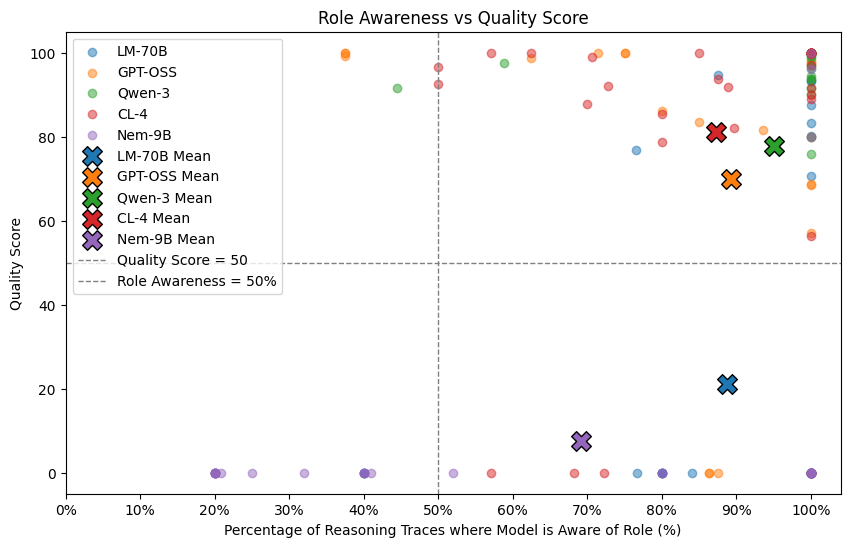

In [69]:
# exclude rows where game is 'clean_up'
no_clean_up_df = trace_df[trace_df['game'] != 'clean_up']
print(no_clean_up_df.shape)
# scatter plot of role_awareness vs main_score
fig, ax = plt.subplots(figsize=(10, 6))
for i, model in enumerate(models):
    model_df = no_clean_up_df[no_clean_up_df['model'] == model]
    color = plt.cm.tab10(i)  # Get a color from the tab10 colormap
    ax.scatter(model_df['role_awareness'], model_df['main_score'], label=model, alpha=0.5, color=color)
for i, model in enumerate(models):
    model_df = no_clean_up_df[no_clean_up_df['model'] == model]
    color = plt.cm.tab10(i)  # Get a color from the tab10 colormap
    main_score_mean = model_df['main_score'].mean()
    role_awareness_mean = model_df['role_awareness'].mean()
    ax.scatter(role_awareness_mean, main_score_mean, label=f'{model} Mean', s=200, edgecolor='black', color=color, marker='X')

# horizontal line at y=50
ax.axhline(y=50, color='gray', linestyle='--', linewidth=1, label='Quality Score = 50')
# vertical line at x=50
ax.axvline(x=50, color='gray', linestyle='--', linewidth=1, label='Role Awareness = 50%')
# make x ticks percentages
ax.set_xticks(np.arange(0, 101, 10))
# make x tick labels percentages
ax.set_xticklabels([f'{i}%' for i in range(0, 101, 10)])
ax.set_xlabel('Percentage of Reasoning Traces where Model is Aware of Role (%)')
ax.set_ylabel('Quality Score')
ax.set_title('Role Awareness vs Quality Score')
ax.legend()
plt.savefig('role_awareness_vs_quality_score.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [73]:
# calculate how many points are both above the horizontal line and to the right of the vertical line
above_and_right_total = 0
above_and_left_total = 0
below_and_right_total = 0
below_and_left_total = 0
for i, model in enumerate(models):
    model_df = no_clean_up_df[no_clean_up_df['model'] == model]
    above_and_right = ((model_df['role_awareness'] > 50) & (model_df['main_score'] > 50)).sum()
    above_and_left = ((model_df['role_awareness'] <= 50) & (model_df['main_score'] > 50)).sum()
    below_and_right = ((model_df['role_awareness'] > 50) & (model_df['main_score'] <= 50)).sum()
    below_and_left = ((model_df['role_awareness'] <= 50) & (model_df['main_score'] <= 50)).sum()
    total = above_and_right + above_and_left + below_and_right + below_and_left
    print(f'{model}: {above_and_right} above and right, {above_and_left} above and left, {below_and_right} below and right, {below_and_left} below and left')
    above_and_right_total += above_and_right
    above_and_left_total += above_and_left
    below_and_right_total += below_and_right
    below_and_left_total += below_and_left
total = above_and_right_total + above_and_left_total + below_and_right_total + below_and_left_total
print(f'Overall: {above_and_right_total}/{total} above and right, {above_and_left_total} above and left, {below_and_right_total} below and right, {below_and_left_total} below and left')
print(f'Overall Percentages: {above_and_right_total/total:.2%} above and right, {above_and_left_total/total:.2%} above and left, {below_and_right_total/total:.2%} below and right, {below_and_left_total/total:.2%} below and left')

LM-70B: 9 above and right, 0 above and left, 24 below and right, 4 below and left
GPT-OSS: 24 above and right, 3 above and left, 9 below and right, 0 below and left
Qwen-3: 28 above and right, 1 above and left, 6 below and right, 1 below and left
CL-4: 29 above and right, 2 above and left, 5 below and right, 0 below and left
Nem-9B: 3 above and right, 0 above and left, 19 below and right, 14 below and left
Overall: 93/181 above and right, 6 above and left, 63 below and right, 19 below and left
Overall Percentages: 51.38% above and right, 3.31% above and left, 34.81% below and right, 10.50% below and left
